In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

# 딥러닝: 데이터의 규칙성을 추출 
- 응용분야: 글씨인식, 문장분류, 값예측, 질병진단, 얼굴인식
- ML/DL의 종류
     *지도학습(입력=독립변수, 타겟=종속변수)
         *분류분석 (타겟변수가 category 변수인 분석. 다중분류와 이진분류) vs 회귀분석 
     *비지도학습(입력변수)
         *군집화 
     *강화학습


- 지도학습에서의 딥러닝 프로그래밍 방식 
   - 1. 데이터 확보 및 생성 
   - 2. 데이터 전처리: 결측치처리, 스케일 조정, 인코딩처리(라벨인코딩, 원핫인코딩),학습, 검증, 시험데이터셋 분리 
   - 3. 모델 구성
   - 4. 모델 학습 과정 설정 
   - 5. 모델 학습시키기(훈련, 검증 데이터셋)
   - 6. 모델 평가(시험 데이터셋) 
   - 7. 모델 저장/사용(입력값이 주어지면 예측값을 받기) 

In [4]:
from tensorflow.keras.utils import to_categorical #분류분석시 원핫인코딩(to_categorical추천)
import pandas as pd #원핫인코딩
from tensorflow.keras.models import Sequential, load_model # 모델 생성, 모델 load
from tensorflow.keras.layers import Dense, Input #모델에 층을 쌓기 위해서
import numpy as np

# 1. 데이타셋 확보하기
# 2. 데이터 전처리

In [6]:
#학습데이터 = 훈련 데이터셋 
x_train = np.array([1,2,3,4,5,6,7,8,9]*10)
y_train = np.array([2,3,4,5,6,7,8,9,10]*10)
#검증데이터, 시험데이터셋
x_val = np.array([1,2,3,4,5,6,7,8,9])
y_val =np.array([2,3,4,5,6,7,8,9,10])

In [26]:
#인코딩 종류
     #라벨인코딩 = 문자를 숫자로
     #원핫인코딩 = 값의 갯수만큼 열을 만들고, 해당 범주에 해당하는 열만 1을 나머지 열은 0을 
        
data= np.array(['aa', 'bb','cc', 'bb', 'bb'])
print('원 데이터:',data)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
#le.fit(data)
#labeling_data=le.transform(data)
labeling_data=le.fit_transform(data)
print('리벨인코딩된 데이터:', labeling_data)
#onehot_encoding_data =to_categorical(data) #에러남
onehot_encoding_data1 =to_categorical(labeling_data)
print('원핫인코딩된 데이터:\n', onehot_encoding_data1)
onehot_encoding_data2 = pd.get_dummies(data)
# onehot_encoding_data2 = pd.get_dummies(labeling_data)
print('원핫인코딩된 데이터:\n', onehot_encoding_data2)

원 데이터: ['aa' 'bb' 'cc' 'bb' 'bb']
리벨인코딩된 데이터: [0 1 2 1 1]
원핫인코딩된 데이터:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]
원핫인코딩된 데이터:
    aa  bb  cc
0   1   0   0
1   0   1   0
2   0   0   1
3   0   1   0
4   0   1   0


In [16]:
data= np.array([1,4,5,4,5])
categorical_onehot=to_categorical(data)
print('to_categorical 이용 \n', categorical_onehot)
getdummies_onehot = pd.get_dummies(data)
print('get_dummies 이용\n', getdummies_onehot)

to_categorical 이용 
 [[0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]]
get_dummies 이용
    1  4  5
0  1  0  0
1  0  1  0
2  0  0  1
3  0  1  0
4  0  0  1


In [20]:
# 분류분석을 위한 종속(타겟)변수의 원핫인코딩
Y_val = to_categorical(y_val)
Y_val

array([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [23]:
Y_train= to_categorical(y_train, 11)
Y_val=to_categorical(y_val)

In [24]:
#딥러닝 모델에 사용될 데이터 
x_train.shape, Y_train.shape, x_val.shape, Y_val.shape

((90,), (90, 11), (9,), (9, 11))

In [25]:
Y_val[0]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

# 3. 모델 구성
- 회귀분석에서의 loss: mse, mae, rmse
- 다중분류에서의 loss:categorical_crossentropy
- 이진분류에서의 loss:binary_crossentropy 
- 분류분석에서의 metrics(평가지표) :accuracy, recall, precision 

In [30]:
model=Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(units=38, activation='sigmoid')) #활성화 함수 : relu, elu, tanh, sigmoid, softmax
model.add(Dense(64, activation='elu'))
model.add(Dense(32, activation='elu'))
model.add(Dense(11, activation='softmax'))#다중분류에서의 출력층 활성화 함수 : softmax
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 38)                76        
                                                                 
 dense_1 (Dense)             (None, 64)                2496      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 11)                363       
                                                                 
Total params: 5,015
Trainable params: 5,015
Non-trainable params: 0
_________________________________________________________________


In [32]:
# 모델 학습과정 설정
model.compile(loss='categorical_crossentropy', 
               optimizer='adam', 
               metrics=['accuracy'])

# 5. 모델 학습시키기 

In [33]:
hist = model.fit(x_train, Y_train, #학습데이터셋(입력변수와 타겟변수)
                 epochs=300,       #학습횟수
                batch_size=10, 
                validation_data=(x_val, Y_val),
                verbose=1)
#verbose=0 :학습로그출력없음/ 1:기본값출력 /2:자세한 로그출력 

Epoch 1/300
9/9 [==============================] - 1s 52ms/step - loss: 2.3222 - accuracy: 0.0556 - val_loss: 2.2139 - val_accuracy: 0.2222
Epoch 2/300
9/9 [==============================] - 0s 8ms/step - loss: 2.1898 - accuracy: 0.2333 - val_loss: 2.1400 - val_accuracy: 0.3333
Epoch 3/300
9/9 [==============================] - 0s 8ms/step - loss: 2.1309 - accuracy: 0.1889 - val_loss: 2.0758 - val_accuracy: 0.2222
Epoch 4/300
9/9 [==============================] - 0s 8ms/step - loss: 2.0552 - accuracy: 0.2778 - val_loss: 2.0117 - val_accuracy: 0.2222
Epoch 5/300
9/9 [==============================] - 0s 9ms/step - loss: 2.0029 - accuracy: 0.2889 - val_loss: 1.9481 - val_accuracy: 0.3333
Epoch 6/300
9/9 [==============================] - 0s 9ms/step - loss: 1.9341 - accuracy: 0.2778 - val_loss: 1.8849 - val_accuracy: 0.3333
Epoch 7/300
9/9 [==============================] - 0s 9ms/step - loss: 1.8632 - accuracy: 0.2444 - val_loss: 1.8144 - val_accuracy: 0.4444
Epoch 8/300
9/9 [=========

9/9 [==============================] - 0s 7ms/step - loss: 0.4054 - accuracy: 0.9667 - val_loss: 0.3932 - val_accuracy: 1.0000
Epoch 60/300
9/9 [==============================] - 0s 7ms/step - loss: 0.4030 - accuracy: 1.0000 - val_loss: 0.3869 - val_accuracy: 1.0000
Epoch 61/300
9/9 [==============================] - 0s 11ms/step - loss: 0.3806 - accuracy: 1.0000 - val_loss: 0.3716 - val_accuracy: 1.0000
Epoch 62/300
9/9 [==============================] - 0s 7ms/step - loss: 0.3735 - accuracy: 1.0000 - val_loss: 0.3554 - val_accuracy: 1.0000
Epoch 63/300
9/9 [==============================] - 0s 8ms/step - loss: 0.3608 - accuracy: 1.0000 - val_loss: 0.3488 - val_accuracy: 1.0000
Epoch 64/300
9/9 [==============================] - 0s 7ms/step - loss: 0.3483 - accuracy: 1.0000 - val_loss: 0.3333 - val_accuracy: 1.0000
Epoch 65/300
9/9 [==============================] - 0s 7ms/step - loss: 0.3321 - accuracy: 1.0000 - val_loss: 0.3230 - val_accuracy: 1.0000
Epoch 66/300
9/9 [==============

9/9 [==============================] - 0s 7ms/step - loss: 0.0580 - accuracy: 1.0000 - val_loss: 0.0562 - val_accuracy: 1.0000
Epoch 118/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0558 - accuracy: 1.0000 - val_loss: 0.0549 - val_accuracy: 1.0000
Epoch 119/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0545 - accuracy: 1.0000 - val_loss: 0.0527 - val_accuracy: 1.0000
Epoch 120/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0535 - accuracy: 1.0000 - val_loss: 0.0518 - val_accuracy: 1.0000
Epoch 121/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0525 - accuracy: 1.0000 - val_loss: 0.0502 - val_accuracy: 1.0000
Epoch 122/300
9/9 [==============================] - 0s 10ms/step - loss: 0.0514 - accuracy: 1.0000 - val_loss: 0.0489 - val_accuracy: 1.0000
Epoch 123/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0476 - accuracy: 1.0000 - val_loss: 0.0469 - val_accuracy: 1.0000
Epoch 124/300
9/9 [=======

9/9 [==============================] - 0s 7ms/step - loss: 0.0140 - accuracy: 1.0000 - val_loss: 0.0137 - val_accuracy: 1.0000
Epoch 176/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0136 - accuracy: 1.0000 - val_loss: 0.0135 - val_accuracy: 1.0000
Epoch 177/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0134 - accuracy: 1.0000 - val_loss: 0.0132 - val_accuracy: 1.0000
Epoch 178/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0132 - accuracy: 1.0000 - val_loss: 0.0129 - val_accuracy: 1.0000
Epoch 179/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0130 - accuracy: 1.0000 - val_loss: 0.0127 - val_accuracy: 1.0000
Epoch 180/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0127 - accuracy: 1.0000 - val_loss: 0.0125 - val_accuracy: 1.0000
Epoch 181/300
9/9 [==============================] - 0s 10ms/step - loss: 0.0125 - accuracy: 1.0000 - val_loss: 0.0122 - val_accuracy: 1.0000
Epoch 182/300
9/9 [=======

9/9 [==============================] - 0s 7ms/step - loss: 0.0055 - accuracy: 1.0000 - val_loss: 0.0054 - val_accuracy: 1.0000
Epoch 234/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0055 - accuracy: 1.0000 - val_loss: 0.0054 - val_accuracy: 1.0000
Epoch 235/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0054 - accuracy: 1.0000 - val_loss: 0.0053 - val_accuracy: 1.0000
Epoch 236/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0053 - accuracy: 1.0000 - val_loss: 0.0052 - val_accuracy: 1.0000
Epoch 237/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0052 - accuracy: 1.0000 - val_loss: 0.0052 - val_accuracy: 1.0000
Epoch 238/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0052 - accuracy: 1.0000 - val_loss: 0.0051 - val_accuracy: 1.0000
Epoch 239/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0051 - accuracy: 1.0000 - val_loss: 0.0050 - val_accuracy: 1.0000
Epoch 240/300
9/9 [========

9/9 [==============================] - 0s 7ms/step - loss: 0.0027 - accuracy: 1.0000 - val_loss: 0.0027 - val_accuracy: 1.0000
Epoch 292/300
9/9 [==============================] - 0s 10ms/step - loss: 0.0027 - accuracy: 1.0000 - val_loss: 0.0027 - val_accuracy: 1.0000
Epoch 293/300
9/9 [==============================] - 0s 9ms/step - loss: 0.0027 - accuracy: 1.0000 - val_loss: 0.0027 - val_accuracy: 1.0000
Epoch 294/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0027 - accuracy: 1.0000 - val_loss: 0.0026 - val_accuracy: 1.0000
Epoch 295/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0026 - accuracy: 1.0000 - val_loss: 0.0026 - val_accuracy: 1.0000
Epoch 296/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0026 - accuracy: 1.0000 - val_loss: 0.0026 - val_accuracy: 1.0000
Epoch 297/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0026 - accuracy: 1.0000 - val_loss: 0.0026 - val_accuracy: 1.0000
Epoch 298/300
9/9 [=======

# 6. 모델 평가하기 (모델 학습과정 살펴보고, evaluate)

In [35]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

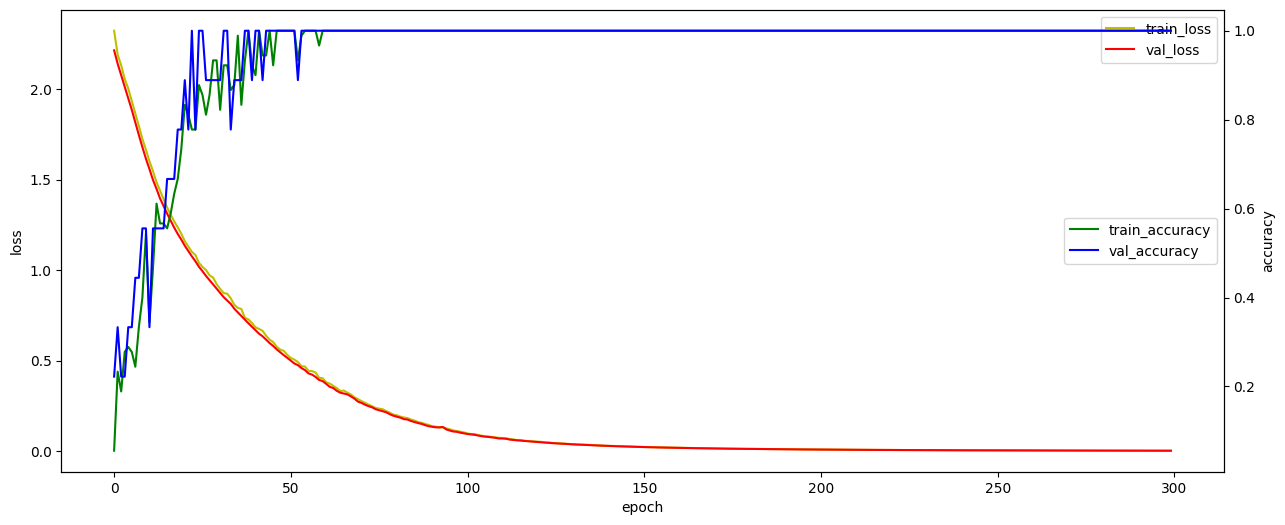

In [48]:
#학습과정 살펴보기 
import matplotlib.pyplot as plt

fig, loss_ax= plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax=loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()



In [52]:
# 모델 평가하기 
score = model.evaluate(x_val, Y_val, batch_size=3)
print( 'loss:', score[0])
print( 'accuracy:', score[1])

3/3 [==============================] - 0s 6ms/step - loss: 0.0025 - accuracy: 1.0000
loss: 0.0024786300491541624
accuracy: 1.0


# 7.모델 저장

In [54]:
model.save('model/02_deep.h5') #모델 저장 파일:h5 이거나 keras 

In [55]:
# 저장된 모델 사용하기 
model1=load_model('model/02_deep.h5')

# 7. 모델 사용

In [57]:
h = model.predict(np.array([5]))
h.argmax()

1/1 [==============================] - 0s 22ms/step


6

In [59]:
model.predict(np.array([5])).argmax()

1/1 [==============================] - 0s 33ms/step


6

In [61]:
# 몇 % 확률로 5라고 예측했나?
h[0, h.argmax()]*100

99.80562925338745

In [64]:
h[0, [5,6,7]]

array([8.2873373e-04, 9.9805629e-01, 1.1149555e-03], dtype=float32)